In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path
from matplotlib.ticker import FormatStrFormatter

ommea dist = "frecuencia normalizada" o "cuentas"

In [97]:
def plot_stability(score_dist, selected_variables, k, ax1=None, ax2=None, show_ylabel=True):

    n_repeats = score_dist.shape[0]
    selected_variables_rate = (selected_variables / n_repeats) * 100

    colors = sns.color_palette("tab10", n_colors=5, as_cmap=False)

    group_size = 20
    n_bars = len(selected_variables_rate)

    bar_colors = [colors[i // group_size] for i in range(n_bars)]

    labels = ["WR", "SR", "WS", "SS", "I"]
    tick_positions = [group_size * i + group_size / 2 - 0.5 for i in range(len(labels))]

    # -----------------------
    # Left: barplot
    # -----------------------
    sns.barplot(
        x=range(len(selected_variables_rate)),
        y=selected_variables_rate,
        hue=range(len(selected_variables_rate)),
        legend=False,
        ax=ax1,
        palette=bar_colors,
        width=1.0
    )

    ax1.set_xticks(tick_positions)
    ax1.set_xticklabels(labels)
    ax1.tick_params(axis="x", rotation=0)

    ax1.set_yticks([0, 50, 100])

    if show_ylabel:
        order_label = k if k != -1 else "OF"
        ax1.set_ylabel(
            "Selection\nrate (%)",
            rotation=0,
            labelpad=15,
            va='center',
            ha="right",               # anchor alignment
            multialignment="right"    # line-by-line alignment
        )
    else:
        ax1.set_ylabel("")
        ax1.tick_params(axis="y", labelleft=False)

    # Remove unused spines (top & right)
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)

    # -----------------------
    # Right: vertical distribution
    # -----------------------
    sns.histplot(
        x=score_dist,
        stat="percent",
        element="step",
        fill=True,
        binwidth=0.1,
        binrange=(-7, 7),
        ax=ax2
    )

    ax2.set_title("")
    ax2.set_xlabel("")# "
    ax2.set_ylim(0, 100)
    #ax2.set_yticks([0,100])

    if show_ylabel:
        ax2.set_ylabel(
            "frequency of\nobtained "+ r"$\Omega$" + " (%)",
            rotation=0,
            labelpad=15,
            va='center',
            ha="right",               # anchor alignment
            multialignment="right"    # line-by-line alignment
        )
    else:
        ax2.set_ylabel("")
        ax2.tick_params(axis="y", length=3)
    
    ax2.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))

    ax2.spines["top"].set_visible(False)
    #ax2.spines["left"].set_visible(False)
    ax2.spines["right"].set_visible(False)


In [8]:
results = np.load("../results/simulated_annealing_stability/sa_stability_N100_5-components_temp.npz", allow_pickle=True)

(
    max_score_dist,
    min_score_dist,
    max_selected_variables,
    min_selected_variables
) = results["max_score_dist"], results["min_score_dist"], results["max_selected_variables"], results["min_selected_variables"]


# Eliminar esto en la version final
max_score_dist = max_score_dist[:,:32]
min_score_dist = min_score_dist[:,:32]

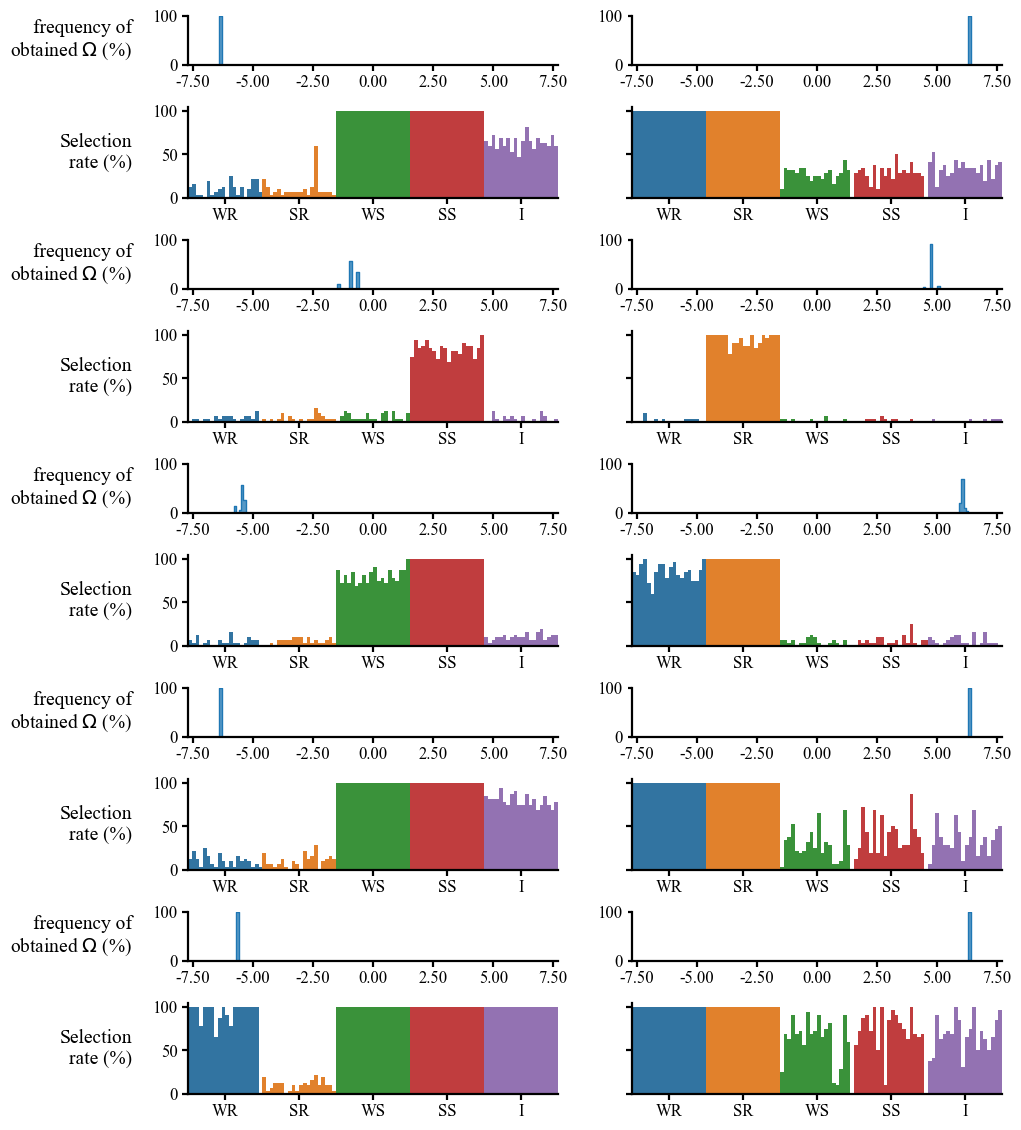

In [100]:
m = 2

plt.rcParams.update({
    # Font
    "font.family": "serif",
    "font.serif": ["Times New Roman"],

    # Axis labels
    "axes.labelsize": 7*m,
    "axes.titlesize": 7*m,

    # Tick labels
    "xtick.labelsize": 6*m,
    "ytick.labelsize": 6*m,

    # Legend (if any)
    "legend.fontsize": 6*m,

    # Lines & ticks
    "axes.linewidth": 0.8*m,
    "xtick.major.width": 0.8*m,
    "ytick.major.width": 0.8*m,
    "xtick.major.size": 2*m,
    "ytick.major.size": 2*m,
})

fig, axes = plt.subplots(
    10, 2,
    figsize=(5.25*m, 7*m),
    gridspec_kw={
        "width_ratios": [5, 5],
        "height_ratios": [
            0.7, 1.3,
            0.7, 1.3,
            0.7, 1.3,
            0.7, 1.3,
            0.7, 1.3
        ],
        "wspace": 0.20,
        "hspace": 0.6
    }
)

# Share x-axis among the axis 0, 2, 4, 6, 8
for i in range(0,10,2):
    axes[i, 0].sharex(axes[0,0])
    axes[i, 1].sharex(axes[0,0])

ks = [-1, 20, 40, 60, 80]
for i in range(0,10,2):

    # Only show y-axis label on the left barplot column (col 0)
    # (col 2 shares y but doesn’t repeat label/ticks)
    plot_stability(
        min_score_dist[i//2],
        min_selected_variables[i//2],
        k=ks[i//2],
        ax1=axes[i+1, 0],
        ax2=axes[i, 0],
        show_ylabel=True
    )

    plot_stability(
        max_score_dist[i//2],
        max_selected_variables[i//2],
        k=ks[i//2],
        ax1=axes[i+1, 1],
        ax2=axes[i, 1],
        show_ylabel=False
    )

Path("./img/simulated_annealing_stability/").mkdir(parents=True, exist_ok=True)
plt.savefig(
    "./img/simulated_annealing_stability/sa_stability_N100_5-components.svg",
)
plt.show()
